In [1]:
import os

print(os.getcwd())

C:\Users\admin\Downloads\SentinelAI\notebooks


In [2]:
import pandas as pd

df = pd.read_csv("../datasets/processed/saas_features_processed.csv")
df.head()

,company_id,user_id,login_time,login_hour,is_weekend,session_duration,failed_login_count,data_transfer_amount,files_accessed,emails_sent,...,avg_login_hour,avg_session,avg_transfer,avg_files,avg_queries,login_deviation,transfer_deviation,session_deviation,query_deviation,file_deviation
0,T006,U00395,2025-01-16 18:50:18,17,0,132.3,0,139.6,12,7,...,12.651261,251.540756,383.613445,10.252101,8.008403,4.348739,244.013445,119.240756,0.991597,1.747899
1,T003,U00170,2025-01-30 07:09:20,12,0,431.1,0,187.2,10,6,...,15.500000,346.062376,295.213861,9.876238,7.722772,3.500000,108.013861,85.037624,1.722772,0.123762
2,T006,U00492,2025-01-13 11:59:24,13,0,343.7,0,154.9,14,4,...,11.769231,293.342510,322.120648,16.206478,11.663968,1.230769,167.220648,50.357490,8.663968,2.206478
3,T004,U00269,2025-02-17 14:51:43,22,0,185.7,0,135.3,5,0,...,16.124088,230.643796,202.892701,10.080292,7.459854,5.875912,67.592701,44.943796,0.540146,5.080292
4,T005,U00383,2025-02-05 15:13:54,19,0,288.2,2,500.1,29,9,...,12.241667,283.370000,212.796667,10.333333,8.000000,6.758333,287.303333,4.830000,12.000000,18.666667


In [3]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
feature_columns = [

    "login_hour",
    "session_duration",
    "failed_login_count",
    "data_transfer_amount",
    "files_accessed",
    "emails_sent",
    "database_queries",
    "usb_usage",
    "vpn_usage",
    "is_weekend",

    "night_login",
    "business_hours",
    "sensitive_access",
    "external_ip",

    "high_transfer",
    "high_db_queries",
    "high_file_access",
    "failed_login_flag",
    "long_session",

    "login_deviation",
    "transfer_deviation",
    "session_deviation",
    "query_deviation",
    "file_deviation"

]

X = df[feature_columns]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(111447, 24)


In [6]:
input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

In [7]:
# Encoder
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)

# Decoder
decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

# Create Model
autoencoder = Model(inputs=input_layer, outputs=decoded)

# Compile
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# View Model Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 24)                  │             408 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,088 (4.25 KB)

 Trainable params: 1,088 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=50,
    batch_size=128,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5173
Epoch 2/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2716
Epoch 3/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2272
Epoch 4/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2159
Epoch 5/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2082
Epoch 6/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2028
Epoch 7/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2003
Epoch 8/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1989
Epoch 9/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1962
Epoch 10/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1940
Epoch 11/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1927
Epoch 12/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1912
Epoch 13/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1896
Epoch 14/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1882
Epoch 15/50
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

In [10]:
reconstructed = autoencoder.predict(X_scaled)

3483/3483 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [11]:
import numpy as np

mse = np.mean(
    np.square(X_scaled - reconstructed),
    axis=1
)

df["reconstruction_error"] = mse

In [12]:
threshold = np.percentile(mse, 75)

print("Threshold:", threshold)

Threshold: 0.2179064386771622


In [13]:
df["ae_prediction"] = (
    df["reconstruction_error"] > threshold
).astype(int)

In [14]:
from sklearn.metrics import classification_report

print(classification_report(
    df["risk_label"],
    df["ae_prediction"]
))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89     82778
           1       0.69      0.67      0.68     28669

    accuracy                           0.84    111447
   macro avg       0.79      0.78      0.79    111447
weighted avg       0.84      0.84      0.84    111447



In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df["risk_label"],
    df["ae_prediction"]
)

print(cm)

[[74115  8663]
 [ 9470 19199]]


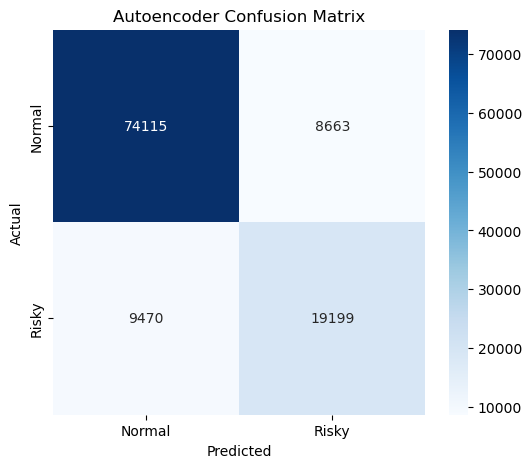

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Risky"],
    yticklabels=["Normal","Risky"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Autoencoder Confusion Matrix")

plt.show()

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(df["risk_label"], df["ae_prediction"]))
print("Precision:", precision_score(df["risk_label"], df["ae_prediction"]))
print("Recall   :", recall_score(df["risk_label"], df["ae_prediction"]))
print("F1 Score :", f1_score(df["risk_label"], df["ae_prediction"]))

Accuracy : 0.8372948576453382
Precision: 0.6890747254324887
Recall   : 0.6696780494610903
F1 Score : 0.6792379402451753


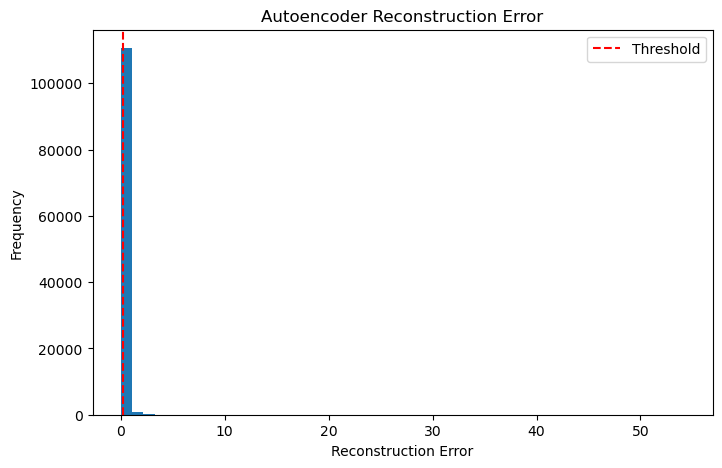

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    df["reconstruction_error"],
    bins=50
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    label="Threshold"
)

plt.title("Autoencoder Reconstruction Error")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

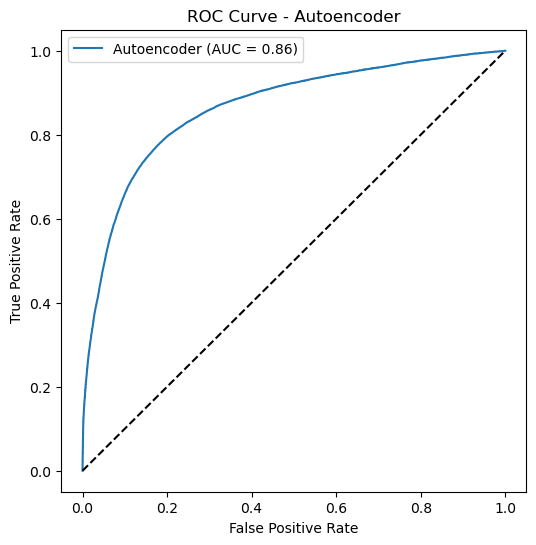

In [22]:
fpr_ae, tpr_ae, _ = roc_curve(
    df["risk_label"],
    df["reconstruction_error"]
)

roc_auc_ae = auc(fpr_ae, tpr_ae)

plt.figure(figsize=(6,6))

plt.plot(
    fpr_ae,
    tpr_ae,
    label=f"Autoencoder (AUC = {roc_auc_ae:.2f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Autoencoder")

plt.legend()

plt.show()

In [26]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt


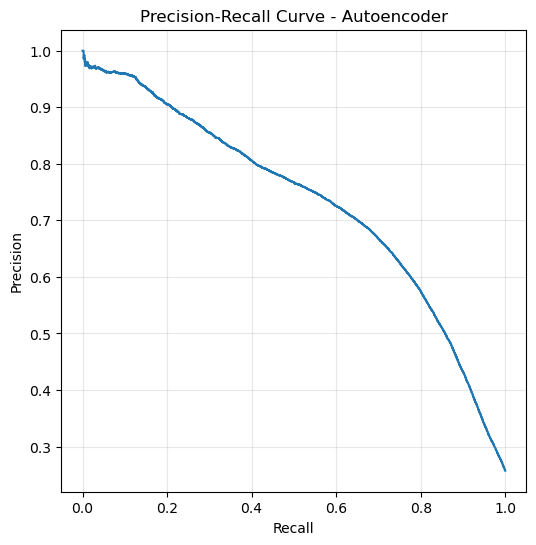

In [28]:
precision_ae, recall_ae, _ = precision_recall_curve(
    df["risk_label"],
    df["reconstruction_error"]
)

plt.figure(figsize=(6,6))

plt.plot(recall_ae, precision_ae)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Autoencoder")

plt.grid(alpha=0.3)

plt.show()

In [29]:
ae_results = df[[
    "reconstruction_error",
    "ae_prediction"
]]

ae_results.to_csv(
    "../datasets/processed/autoencoder_results.csv",
    index=False
)